# Latent JacobianODE — Fully Observed 3D Lorenz (Identity Test)

This notebook tests the **Latent JacobianODE** model in the **easiest possible setting**:
- **Input**: Fully observed 3D Lorenz system (all 3 coordinates visible, no noise)
- **Latent space**: 3D (same dimension as the true system)
- **Encoder**: LRU (Linear Recurrent Unit) **without** positional encoding — maps `(B, T, 3)` → `(B, T, 3)`
- **Decoder**: Pointwise MLP — maps `(B, T, 3)` → `(B, T, 3)`

> **If this identity test fails, there is a fundamental bug.** If it passes, we get the
> green light to move to harder partial-observation / dimension-reduction settings.

## Two Validation Tests

1. **Lyapunov Exponent Test** — Latent Jacobians → QR-decomposition Lyapunov exponents
   should match the known Lorenz spectrum λ ≈ (+0.91, 0.0, −14.57).

2. **Composite Jacobian Test** — The autodifferentiated composition

   $$J_D \; J_{\mathrm{ODE}} \; J_E \approx J_{\mathrm{true}}$$

   where
   - $J_E = \partial z_t / \partial x_t$ — encoder Jacobian (autograd)
   - $J_{\mathrm{ODE}}$ — predicted continuous latent Jacobian from the Jacobian MLP
   - $J_D = \partial \hat{x}_t / \partial z_t$ — decoder Jacobian (autograd)
   - $J_{\mathrm{true}}$ — analytical Lorenz Jacobian at $x_t$

   Since the normalization is a global scalar, $J_{\mathrm{true}}$ is identical in
   normalized and raw coordinates.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from torch.autograd.functional import jacobian as autograd_jacobian
from tqdm.auto import tqdm

In [3]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    make_model,
    train_model,
)
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.jacobians.data.processing import normalize_data

In [4]:
seed_everything(42)

42

## 1. Hyperparameters

### Data
We simulate standard Lorenz (σ=10, ρ=28, β=8/3) and observe **all three** dimensions
with **no observation noise** — the cleanest possible test.

In [5]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
OBS_NOISE      = 0.05           # No noise: cleanest identity test
OBSERVED_INDICES = [0, 1, 2]  # Observe ALL three Lorenz dimensions
N_PERIODS      = 15            # Lorenz periods to simulate
PTS_PER_PERIOD = 100           # Temporal resolution (dt ≈ 0.015)
NUM_ICS        = 32            # Independent initial conditions

# Known Lorenz Lyapunov exponents (σ=10, ρ=28, β=8/3)
TRUE_LYAPUNOV  = [0.91, 0.0, -14.57]

SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"

In [6]:
# ----------------------------------------------------------------
# Encoder / Latent space hyperparameters
# ----------------------------------------------------------------
# 3D → 3D: exact identity embedding.  If the model can't do this,
# there is a fundamental problem.
N_LATENT    = 3      # Must equal the true system dimension

# LRU encoder (no positional encoding — temporal info captured by recurrent state)
SSM_D_MODEL   = 64     # Internal model channel width
SSM_D_STATE   = 32     # Complex state dimension per channel
SSM_N_LAYERS  = 3      # Number of stacked LRU layers
SSM_R_MIN     = 0.9    # Minimum initial |lambda| (0 = may decay to zero)
SSM_R_MAX     = 0.999   # Maximum initial |lambda| (near unit circle = longer memory)
SSM_FFN_EXPAND = 4     # FFN hidden dim = d_model * ffn_expand (GEGLU nonlinearity)
SSM_DROPOUT   = 0.1

# Decoder MLP (pointwise: z_t → x̂_t)
DECODER_HIDDEN = 128
DECODER_LAYERS = 2

In [7]:
# ----------------------------------------------------------------
# Jacobian MLP hyperparameters
# ----------------------------------------------------------------
# Input dim = N_LATENT = 3, Output dim = N_LATENT^2 = 9.
# A small MLP is sufficient for a 3-dimensional system.
# JAC_HIDDEN_DIM  = [64, 128, 128]
JAC_HIDDEN_DIM = [512, 512, 512]
JAC_NUM_LAYERS  = 3
JAC_ACTIVATION  = 'silu'

In [8]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
MAX_EPOCHS               = 150
LIMIT_TRAIN_BATCHES      = 200   # steps per epoch
LIMIT_VAL_BATCHES        = 50
ACCUMULATE_GRAD_BATCHES  = 1
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-4

ENCODER_WARMUP_EPOCHS    = 0    # Pre-train autoencoder before Jacobian MLP
TRAJ_INIT_STEPS          = 15   # Init steps for JacobianODEint
PREDICTION_STEPS         = 10   # Steps to predict forward
# LOOP_CLOSURE_WEIGHT      = 0 #***** INCREASED AFTER******
LOOP_CLOSURE_WEIGHT      = 1e-3
RECONSTRUCTION_LOSS_WEIGHT = 1.0
INTERP_PTS               = 4
INNER_N                  = 20

# Stride between JacobianODE sub-windows in the latent trajectory.
# With seq_length=50, window=25, stride=5 → 6 sub-windows per batch element.
JAC_WINDOW_STRIDE        = 5

EARLY_STOPPING_PATIENCE  = 5

In [9]:
# ----------------------------------------------------------------
# Sequence length calculation
# ----------------------------------------------------------------
# For a sequence-based encoder (SSM): latent trajectory T' = seq_length.
# The JacobianODE sub-window needs TRAJ_INIT_STEPS + PREDICTION_STEPS timesteps.
# We add extra headroom to allow JAC_WINDOW_STRIDE to extract multiple sub-windows.
#
#   n_sub_windows = (T' - jac_window) // JAC_WINDOW_STRIDE + 1
#   => with SEQ_LENGTH=50:  (50 - 25) // 5 + 1 = 6 sub-windows per batch element

JAC_WINDOW     = TRAJ_INIT_STEPS + PREDICTION_STEPS   # = 25
SEQ_LENGTH     = JAC_WINDOW + JAC_WINDOW_STRIDE * 5   # = 50  (6 sub-windows)

n_sub_windows = (SEQ_LENGTH - JAC_WINDOW) // JAC_WINDOW_STRIDE + 1
print(f"JacobianODE window:      {JAC_WINDOW} = {TRAJ_INIT_STEPS} init + {PREDICTION_STEPS} pred")
print(f"Dataset sequence length: {SEQ_LENGTH}")
print(f"Latent trajectory T':    {SEQ_LENGTH}  (SSM — no shrinkage)")
print(f"Sub-windows per batch:   {n_sub_windows}")
print(f"Effective samples/step:  {BATCH_SIZE * n_sub_windows}")

JacobianODE window:      25 = 15 init + 10 pred
Dataset sequence length: 50
Latent trajectory T':    50  (SSM — no shrinkage)
Sub-windows per batch:   6
Effective samples/step:  192


## 2. Config Setup

We use the `model=latent_ssm` config with:
- `n_input=3` (all three Lorenz dims observed)
- `n_latent=3`
- `use_positional_encoding=False` (LRU has implicit temporal ordering via its recurrent state)
- `r_max=0.99`, `ffn_expand=2` (LRU-specific: magnitude bound + GEGLU feedforward)

In [10]:
overrides = [
    # --- Model: LRU encoder without positional encoding ---
    "model=latent_ssm",
    f"model.encoder.n_input={len(OBSERVED_INDICES)}",   # 3
    f"model.encoder.n_latent={N_LATENT}",               # 3
    f"model.encoder.d_model={SSM_D_MODEL}",
    f"model.encoder.d_state={SSM_D_STATE}",
    f"model.encoder.n_layers={SSM_N_LAYERS}",
    f"model.encoder.r_min={SSM_R_MIN}",
    f"model.encoder.r_max={SSM_R_MAX}",
    f"model.encoder.ffn_expand={SSM_FFN_EXPAND}",
    f"model.encoder.dropout={SSM_DROPOUT}",
    "model.encoder.use_positional_encoding=False",      # No PE
    f"model.encoder.decoder_hidden={DECODER_HIDDEN}",
    f"model.encoder.decoder_layers={DECODER_LAYERS}",
    "model.encoder.context_margin=0",

    # --- Jacobian MLP ---
    f"model.params.hidden_dim={JAC_HIDDEN_DIM}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # --- Prediction steps ---
    f"model.prediction_steps={PREDICTION_STEPS}",

    # --- Data: fully observed Lorenz ---
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.train_test_params.delay_embedding_params.observed_indices={list(OBSERVED_INDICES)}",
    "data.train_test_params.delay_embedding_params.n_delays=1",

    # --- Sequence length ---
    f"data.train_test_params.seq_length={SEQ_LENGTH}",

    # --- Save directory ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.logger_save_dirs={SAVE_DIR}",

    # --- Training hyperparameters ---
    f"training.batch_size={BATCH_SIZE}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.loop_closure_weight={LOOP_CLOSURE_WEIGHT}",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",

    # --- Teacher forcing ---
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",

    # --- JacobianODEint ---
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",

    # --- Trainer ---
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",

    # --- Early stopping ---
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)

print("Lightning target:", cfg.training.lightning._target_)
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")
print(f"Encoder: n_input={cfg.model.encoder.n_input}, n_latent={cfg.model.encoder.n_latent}")
print(f"         use_positional_encoding={cfg.model.encoder.use_positional_encoding}")
print(f"         r_min={cfg.model.encoder.r_min}, r_max={cfg.model.encoder.r_max}, ffn_expand={cfg.model.encoder.ffn_expand}")

Lightning target: JacobianODE.models.latent_jacobian.LitLatentJacobianODE
Jacobian MLP: input_dim=3, output_dim=9
Encoder: n_input=3, n_latent=3
         use_positional_encoding=False
         r_min=0.9, r_max=0.999, ffn_expand=4


In [11]:
print(OmegaConf.to_yaml(cfg))

logger: wandb
wandb_entity: JacobianODE
training:
  batch_size: 32
  run_number: 0
  batch_window_length: null
  batch_stride: null
  lightning:
    _target_: JacobianODE.models.latent_jacobian.LitLatentJacobianODE
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    k_scale: 1
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    alpha_teacher_forcing: 1
    teacher_forcing_annealing: true
    gamma_teacher_forcing: 0.999
    teacher_forcing_update_interval: 5
    teacher_forcing_steps: 1
    min_alpha_teacher_forcing: 0
    alpha_validation: 0
    obs_noise_scale: 0
    jac_penalty: 0.0
    jac_norm_ord: fro
    reconstruction_loss_weight: 1.0
    loop_closure_training: true
    loop_closure_weight: 0.001
    n_loop_pts: 20
    mix_trajectories: true
    loop_closure_interp_pts: 20
    loop_closure_int_method: Trapezoid
    n_loops: null
    jacobianODEint_kwargs:
      traj_init_steps: 15
  

## 3. Generate Trajectories and Create DataLoaders

In [12]:
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1500, 3)
Time step dt = 0.0150


In [13]:
# Postprocess (no noise since OBS_NOISE=0.0), then z-score normalize.
# Normalization is global scalar: x_norm = (x - mu) / sigma.
# Key consequence: J_lorenz(x_norm) = J_lorenz(x_raw)  [sigma cancels]
values = postprocess_data(cfg, sol["values"])
values, mu, sigma = normalize_data(values)
print(f"Postprocessed shape: {values.shape}")
print(f"Normalization: mu={mu:.4f}, sigma={sigma:.4f}")

Postprocessed shape: (32, 1500, 3)
Normalization: mu=8.4429, sigma=14.2548


In [14]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

sample_batch = next(iter(train_dl))
print(f"\nBatch shape: {sample_batch.shape}")
print(f"  (B={sample_batch.shape[0]}, T={sample_batch.shape[1]}, D={sample_batch.shape[2]})")

Sequence Indices:   0%|          | 0/1450 [00:00<?, ?it/s]

Train dataset shape: torch.Size([31900, 50, 3])
Validation dataset shape: torch.Size([10150, 50, 3])
Test dataset shape: torch.Size([4350, 50, 3])
Train trajectories dataset shape: torch.Size([22, 1500, 3])
Validation trajectories dataset shape: torch.Size([7, 1500, 3])
Test trajectories dataset shape: torch.Size([3, 1500, 3])

Batch shape: torch.Size([32, 50, 3])
  (B=32, T=50, D=3)


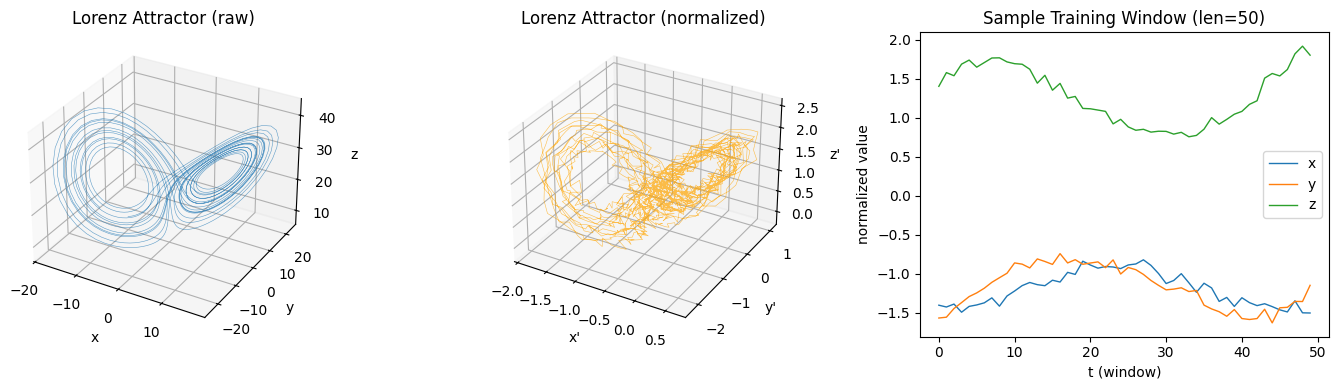

In [15]:
fig = plt.figure(figsize=(14, 4))

# 3D attractor (raw)
ax1 = fig.add_subplot(131, projection='3d')
traj0 = sol["values"][0]
ax1.plot(traj0[:, 0], traj0[:, 1], traj0[:, 2], lw=0.4, alpha=0.7)
ax1.set_title("Lorenz Attractor (raw)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

# Normalized attractor
ax2 = fig.add_subplot(132, projection='3d')
traj_n = values[0]  # normalized, shape (T, 3)
ax2.plot(traj_n[:, 0], traj_n[:, 1], traj_n[:, 2], lw=0.4, alpha=0.7, color='orange')
ax2.set_title("Lorenz Attractor (normalized)")
ax2.set_xlabel("x'"); ax2.set_ylabel("y'"); ax2.set_zlabel("z'")

# Sample training sequences
ax3 = fig.add_subplot(133)
for dim, color, label in zip(range(3), ['C0', 'C1', 'C2'], ['x', 'y', 'z']):
    ax3.plot(sample_batch[0, :, dim].numpy(), color=color, lw=1.0, label=label)
ax3.set_xlabel("t (window)"); ax3.set_ylabel("normalized value")
ax3.set_title(f"Sample Training Window (len={SEQ_LENGTH})")
ax3.legend()

plt.tight_layout()
plt.show()

## 4. Create the Latent JacobianODE Model

In [16]:
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, verbose=True)

# Set attributes not handled automatically by make_model
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
lit_model.encoder_warmup_epochs   = ENCODER_WARMUP_EPOCHS
lit_model.jac_window_stride       = JAC_WINDOW_STRIDE

print(f"\nModel type:         {type(lit_model).__name__}")
print(f"Encoder type:       {type(lit_model.encoder).__name__}")
print(f"  inner encoder:    {type(lit_model.encoder.encoder).__name__}")
print(f"  use_pos_enc:      {lit_model.encoder.encoder.pos_enc}")
print(f"  context_margin:   {lit_model.encoder.context_margin}")
print(f"Prediction steps:   {lit_model.prediction_steps}")
print(f"Jac window stride:  {lit_model.jac_window_stride}")
print(f"Warmup epochs:      {lit_model.encoder_warmup_epochs}")
print(f"dt:                 {lit_model.dt:.4f}")
print(f"True Lyapunov:      {TRUE_LYAPUNOV}")

enc_params = sum(p.numel() for p in lit_model.encoder.parameters())
jac_params = sum(p.numel() for p in lit_model.model.parameters())
print(f"\nParameters — encoder: {enc_params:,}  |  Jacobian MLP: {jac_params:,}  |  total: {enc_params+jac_params:,}")


Model type:         LitLatentJacobianODE
Encoder type:       SequenceAutoencoder
  inner encoder:    SSMSequenceEncoder
  use_pos_enc:      None
  context_margin:   0
Prediction steps:   10
Jac window stride:  5
Warmup epochs:      0
dt:                 0.0150
True Lyapunov:      [0.91, 0.0, -14.57]

Parameters — encoder: 204,870  |  Jacobian MLP: 531,977  |  total: 736,847


## 5. Sanity Check: Forward Pass

In [17]:
lit_model.eval()
with torch.no_grad():
    # 1. Encode
    z = lit_model.encode_trajectory(sample_batch)
    print(f"Encoded latent shape:  {z.shape}")
    print(f"  (B={z.shape[0]}, T'={z.shape[1]}, D_latent={z.shape[2]})")

    # 2. Predict Jacobians in latent space
    jacs = lit_model.compute_jacobians(z)  # (B, T', 3, 3)
    print(f"Jacobians shape:       {jacs.shape}")

    # 3. Decode
    decoded = lit_model.decode_trajectory(z)
    print(f"Decoded shape:         {decoded.shape}")

    # 4. Full trajectory step
    result = lit_model.trajectory_model_step(sample_batch)
    print(f"\nTrajectory step loss:  {result['loss'].item():.6f}")
    print(f"Metrics:               {result['metric_vals']}")

# Quick gradient check
lit_model.train()
loss = lit_model.training_step(sample_batch, batch_idx=0)
loss.backward()
enc_grad  = max(p.grad.abs().max().item() for p in lit_model.encoder.parameters() if p.grad is not None)
jac_grad  = max(p.grad.abs().max().item() for p in lit_model.model.parameters()   if p.grad is not None)
print(f"\nTraining loss:         {loss.item():.6f}")
print(f"Max encoder grad:      {enc_grad:.2e}")
print(f"Max Jacobian MLP grad: {jac_grad:.2e}")
lit_model.zero_grad()

Encoded latent shape:  torch.Size([32, 50, 3])
  (B=32, T'=50, D_latent=3)
Jacobians shape:       torch.Size([32, 50, 3, 3])
Decoded shape:         torch.Size([32, 50, 3])

Trajectory step loss:  0.799019
Metrics:               {'mase': tensor(3.3247), 'r2_score': tensor(0.1507)}

Training loss:         1.589370
Max encoder grad:      1.51e+00
Max Jacobian MLP grad: 2.76e-04


## 6. Train the Model

In [18]:
import os, wandb
try:
    wandb.finish(quiet=True)
except Exception:
    pass

In [19]:
# Re-create model to reset any gradient state from the sanity check above.
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, verbose=False)
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
lit_model.encoder_warmup_epochs   = ENCODER_WARMUP_EPOCHS
lit_model.jac_window_stride       = JAC_WINDOW_STRIDE

RUN_NAME = f"latent_jac_lorenz_3d_full_n{N_LATENT}_ssm_nope_p{PREDICTION_STEPS}"

train_model(
    cfg=cfg,
    lit_model=lit_model,
    train_dataloaders=train_dl,
    val_dataloaders=val_dl,
    name=RUN_NAME,
    project="LatentLorenz__JacobianODE",
    entity="JacobianODE",
)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: adamjeisen (JacobianODE). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64 ...
GPU available: True (cuda), used: True

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

wandb: WARNING Unable to render Widget, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


# 7. Load Model and Test

In [39]:
# run_id = 'y7mto8m6'
run_id = '84v8ev7x'

In [ ]:

# ----------------------------------------------------------------
# Load the trained run from Weights & Biases
# ----------------------------------------------------------------
# Requires Sections 1–2 to have been run (defines TRUE_LYAPUNOV,
# JAC_WINDOW_STRIDE, ENCODER_WARMUP_EPOCHS, SAVE_DIR, etc.)
#
# What this block does:
#   1. Re-generates trajectories from the saved run config
#   2. Normalizes data (z-score, same as Section 3) → gives mu, sigma
#   3. Creates fresh dataloaders from normalized data
#   4. Loads the best checkpoint (lowest mean val loss)
#   5. Restores runtime attributes set manually after model creation

from JacobianODE.jacobians import load_run, load_checkpoint
from JacobianODE.jacobians.data.processing import normalize_data

# W&B path: entity/project
PROJECT_PATH = f"JacobianODE/LatentLorenz__JacobianODE"

# ---- Step 1: rebuild architecture + raw trajectory data ----
run, cfg, eq, dt, _values_raw, _, _, _, _, lit_model = load_run(
    PROJECT_PATH,
    run_id=run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# ---- Step 2: normalize (must match training-time normalization) ----
values, mu, sigma = normalize_data(_values_raw)
print(f"\nNormalization: mu={mu:.4f}, sigma={sigma:.4f}")

# ---- Step 3: dataloaders from normalized data ----
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

# ---- Step 4: load best checkpoint ----
load_checkpoint(run, cfg, lit_model, save_dir=SAVE_DIR, verbose=True)

# ---- Step 5: restore attributes not stored in the wandb config ----
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
# jac_window_stride is stored as null in the config (set manually during training)
lit_model.jac_window_stride = JAC_WINDOW_STRIDE          # = 5 for this run
# encoder_warmup_epochs is passed automatically by make_model when stored in cfg.model,
# but set explicitly here as a safeguard
lit_model.encoder_warmup_epochs = ENCODER_WARMUP_EPOCHS  # = 0 for this run

lit_model.eval()
print(f"\nLoaded run: {run.name}  (id={run.id})")
print(f"  dt={dt:.4f},  mu={mu:.4f},  sigma={sigma:.4f}")
print(f"  jac_window_stride={lit_model.jac_window_stride}")
print(f"  encoder_warmup_epochs={lit_model.encoder_warmup_epochs}")
print(f"  true_lyapunov_exponents={lit_model.true_lyapunov_exponents.tolist()}")
print(f"\nModel ready for testing (Sections 7+).")



Normalization: mu=8.4429, sigma=14.2548


Sequence Indices:   0%|          | 0/1450 [00:00<?, ?it/s]

Train dataset shape: torch.Size([31900, 50, 3])
Validation dataset shape: torch.Size([10150, 50, 3])
Test dataset shape: torch.Size([4350, 50, 3])
Train trajectories dataset shape: torch.Size([22, 1500, 3])
Validation trajectories dataset shape: torch.Size([7, 1500, 3])
Test trajectories dataset shape: torch.Size([3, 1500, 3])

Loaded run: MLP__hidden_dim_[512, 512, 512]__num_layers_3__residuals_False__dropout_0.0__activation_silu__batch_size_32__optimizer_AdamW__optimizer_kwargs_{'lr': 0.0001, 'weight_decay': 0.0001}__use_scheduler_True__min_lr_1e-06__k_scale_1__gradient_clip_val_1.0__gradient_clip_algorithm_norm__alpha_teacher_forcing_1__teacher_forcing_annealing_True__gamma_teacher_forcing_0.999__teacher_forcing_update_interval_5__teacher_forcing_steps_1__min_alpha_teacher_forcing_0__alpha_validation_0__obs_noise_scale_0.0000__jac_penalty_0.0__jac_norm_ord_fro__reconstruction_loss_weight_1.0__loop_closure_training_True__loop_closure_weight_0.0001__n_loop_pts_20__mix_trajectories_Tru

In [41]:
sample_batch = test_dl.dataset.sequence[np.random.choice(np.arange(len(test_dl.dataset.sequence)), size=(128,), replace=False)]

In [42]:
# PROCESS SAMPLE BATCH
with torch.no_grad():
    latent_traj = lit_model.encode_trajectory(sample_batch)
    traj_decoded = lit_model.decode_trajectory(latent_traj)

    traj_ret = lit_model.trajectory_model_step(sample_batch, alpha_teacher_forcing=0.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

# PROCESS TEST TRAJS
test_trajs = trajs['test_trajs'].sequence
with torch.no_grad():
    latent_traj_full = lit_model.encode_trajectory(test_trajs)
    traj_decoded_full = lit_model.decode_trajectory(latent_traj_full)
    jacs_full = lit_model.compute_jacobians(latent_traj_full)
    lyaps_full = lit_model.compute_lyapunov_exponents(jacs_full, dt)

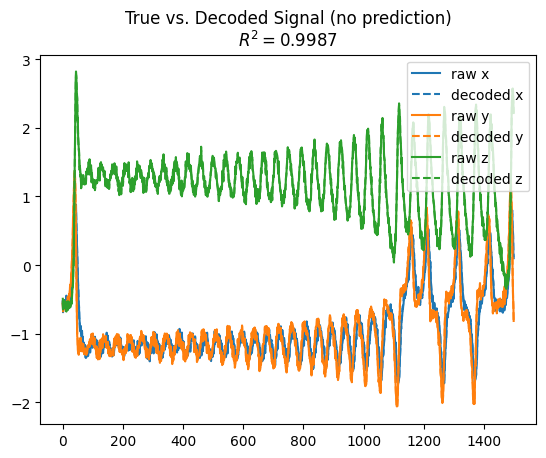

In [43]:
from sklearn.metrics import r2_score
dim_names = ['x', 'y', 'z']
for i in range(3):
    plt.plot(test_trajs[0, :, i].numpy(), c=f"C{i}", label=f'raw {dim_names[i]}')
    plt.plot(traj_decoded_full[0, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {dim_names[i]}')
plt.title(f"True vs. Decoded Signal (no prediction)\n$R^2 = {r2_score(test_trajs.reshape(-1, 3), traj_decoded_full.reshape(-1, 3)):.4f}$")
plt.legend()
plt.show()

In [44]:
lyaps_full.mean(axis=0)

tensor([ -0.1942,  -0.4067, -13.6726])

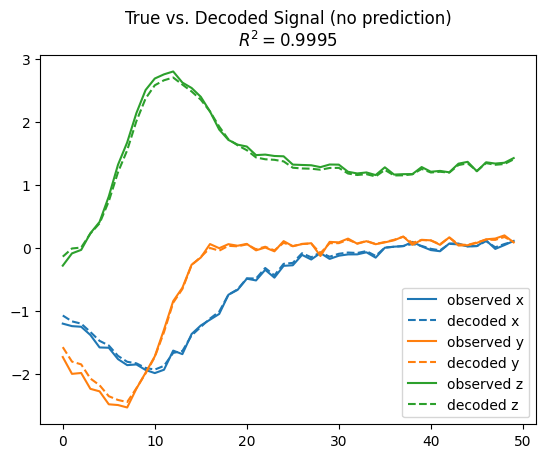

In [45]:
from JacobianODE.jacobians.metrics import r2_score
dim_names = ['x', 'y', 'z']
# plot the worst ind
plot_ind = ((sample_batch - traj_decoded)**2).mean(axis=(1, 2)).argmax()
for i in range(3):
    plt.plot(sample_batch[plot_ind, :, i].numpy(), c=f"C{i}", label=f'observed {dim_names[i]}')
    plt.plot(traj_decoded[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {dim_names[i]}')
plt.title(f"True vs. Decoded Signal (no prediction)\n$R^2 = {r2_score(sample_batch.reshape(-1, 3), traj_decoded.reshape(-1, 3)):.4f}$")
plt.legend()
plt.show()

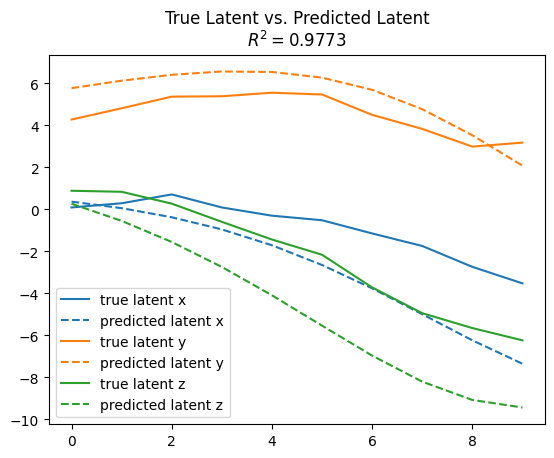

In [46]:
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
# plot the worst ind
plot_ind = ((latent_targets - z_pred[:, traj_init_steps:, :])**2).mean(axis=(1, 2)).argmax()
for i in range(3):
    plt.plot(latent_targets[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true latent {dim_names[i]}')
    plt.plot(z_pred[plot_ind, traj_init_steps:, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted latent {dim_names[i]}')
plt.legend()
r2_val = r2_score(latent_targets.reshape(-1, 3), z_pred[:, traj_init_steps:, :].reshape(-1, 3))
plt.title(f"True Latent vs. Predicted Latent\n$R^2 = {r2_val:.4f}$")
plt.show()

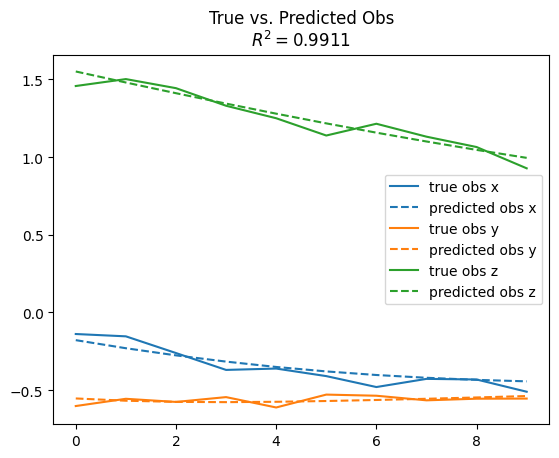

In [47]:
# plot the worst ind
# plot_ind = ((targets - decoded)**2).mean(axis=(1, 2)).argmax()
plot_ind = ((targets - decoded)**2).mean(axis=(1, 2)).argmin()
for i in range(3):
    plt.plot(targets[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true obs {dim_names[i]}')
    plt.plot(decoded[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted obs {dim_names[i]}')
plt.legend()
r2_val = r2_score(targets.reshape(-1, 3), decoded.reshape(-1, 3))
plt.title(f"True vs. Predicted Obs\n$R^2 = {r2_val:.4f}$")
plt.show()

## 8. Test 1 — Lyapunov Exponent Comparison

We encode a long validation trajectory, compute the latent Jacobians via the
learned Jacobian MLP, and then run the standard QR-decomposition Lyapunov algorithm.

Because the true state is **3-dimensional**, all three Lyapunov exponents from the
latent model should match the Lorenz spectrum.

Known Lorenz values: **λ₁ ≈ +0.91, λ₂ ≈ 0.0, λ₃ ≈ −14.57**

In [33]:
lit_model.eval()

# Collect all validation latents
all_z   = []
all_obs = []
with torch.no_grad():
    n_iters = 50
    iterator = tqdm(total=n_iters)
    for batch in val_dl:
        z = lit_model.encode_trajectory(batch)
        all_z.append(z)
        all_obs.append(batch)
        iterator.update(1)
        if iterator.n >= n_iters:
            break
    iterator.close()

z_all   = torch.cat(all_z,   dim=0)  # (N_val, T', 3)
obs_all = torch.cat(all_obs, dim=0)  # (N_val, T,  3)
print(f"Validation latent bank: {z_all.shape}")

  0%|          | 0/50 [00:00<?, ?it/s]

RuntimeError: DataLoader worker (pid(s) 157322, 157323) exited unexpectedly

In [ ]:
# Compute Lyapunov exponents from a long concatenated trajectory
# (take first ~30 val sequences and chain them)
N_TRAJ_LYAP = min(30, z_all.shape[0])
z_long = z_all[:N_TRAJ_LYAP].reshape(-1, N_LATENT).unsqueeze(0)  # (1, T_long, 3)

with torch.no_grad():
    jacs_long = lit_model.compute_jacobians(z_long)[0]           # (T_long, 3, 3)
    pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_long, dt)

print("Predicted Lyapunov exponents (latent space):")
for i, le in enumerate(pred_lyap):
    print(f"  λ_{i+1} = {le.item():+.4f}")

print("\nTrue Lorenz Lyapunov exponents:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  λ_{i+1} = {le:+.4f}")

true_t = torch.tensor(TRUE_LYAPUNOV)
lyap_mse = ((pred_lyap - true_t) ** 2).mean().item()
print(f"\nLyapunov MSE: {lyap_mse:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

x     = np.arange(N_LATENT)
pred_np = pred_lyap.numpy()
true_np = np.array(TRUE_LYAPUNOV)

ax.bar(x - 0.18, pred_np,  width=0.35, label="Predicted (latent)", alpha=0.8, color='C0')
ax.bar(x + 0.18, true_np,  width=0.35, label="True (Lorenz)",      alpha=0.8, color='C1')

ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xticks(x)
ax.set_xticklabels([f'λ_{i+1}' for i in range(N_LATENT)])
ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum  (MSE={lyap_mse:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Test 2 — Composite Jacobian: $J_D \, J_{\mathrm{ODE}} \, J_E \approx J_{\mathrm{true}}$

We verify that the autodifferentiated composition of encoder, predicted latent
Jacobian, and decoder recovers the true Lorenz Jacobian.

**Three Jacobians**:
| Symbol | Shape | Computed via |
|--------|-------|--------------|
| $J_E = \partial z_t / \partial x_t$ | (3, 3) | `autograd` through SSM encoder |
| $J_{\mathrm{ODE}}$ | (3, 3) | Jacobian MLP output at $z_t$ |
| $J_D = \partial \hat{x}_t / \partial z_t$ | (3, 3) | `autograd` through pointwise decoder |

**Lorenz Jacobian** at $x = (x_1, x_2, x_3)$ (in normalized coords = same as raw since normalization is a global scalar):
$$
J_{\mathrm{true}}(x) = \begin{pmatrix}
-\sigma & \sigma & 0 \\
\rho - x_3 & -1 & -x_1 \\
x_2 & x_1 & -\beta
\end{pmatrix}
$$

**Expected result**: $J_D J_{\mathrm{ODE}} J_E \approx J_{\mathrm{true}}$ entry-by-entry.

In [48]:
# ---------------------------------------------------------------
# Helper: analytical Lorenz Jacobian
# Note: Since normalization is x_norm = (x - mu)/sigma (global scalar),
# J_lorenz(x_norm) == J_lorenz(x_raw).  Pass denormalized x.
# ---------------------------------------------------------------
def lorenz_jacobian(x_raw, sigma_lz=10.0, rho=28.0, beta=8.0/3.0):
    """Analytical Lorenz Jacobian at x_raw = (x1, x2, x3)."""
    x1, x2, x3 = float(x_raw[0]), float(x_raw[1]), float(x_raw[2])
    return torch.tensor([
        [-sigma_lz, sigma_lz,    0.0 ],
        [rho - x3,  -1.0,       -x1  ],
        [x2,         x1,        -beta],
    ], dtype=torch.float32)


# ---------------------------------------------------------------
# Helper: encoder Jacobian  J_E = d(z_t)/d(x_t)
# We replace x_t in the full sequence and differentiate.
# For the SSM this gives the *partial* Jacobian w.r.t. x_t
# (history x_{0:t-1} is treated as fixed constants).
# ---------------------------------------------------------------
def compute_J_E(lit_model, x_seq, t_idx):
    """
    Args:
        x_seq : (1, T, D_obs) — single sequence (batch dim = 1)
        t_idx : int           — timestep to differentiate at
    Returns:
        J_E : (D_latent, D_obs) tensor
    """
    x_detached = x_seq.detach()

    def f(x_t):
        # x_t: (D_obs,) — the input we differentiate w.r.t.
        x_new = torch.cat([
            x_detached[:, :t_idx, :],
            x_t.view(1, 1, -1),
            x_detached[:, t_idx+1:, :],
        ], dim=1)  # (1, T, D_obs)
        z = lit_model.encoder.encode(x_new)  # (1, T, D_latent)
        return z[0, t_idx]                   # (D_latent,)

    return autograd_jacobian(f, x_detached[0, t_idx])  # (D_latent, D_obs)


# ---------------------------------------------------------------
# Helper: decoder Jacobian  J_D = d(decode(z_t))/d(z_t)
# ---------------------------------------------------------------
def compute_J_D(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_D : (D_obs, D_latent) tensor
    """
    def f(z):
        # z: (D_latent,) → (D_obs,)
        return lit_model.encoder.decode(z.unsqueeze(0)).squeeze(0)

    return autograd_jacobian(f, z_t)  # (D_obs, D_latent)


# ---------------------------------------------------------------
# Helper: predicted latent Jacobian  J_ODE = Jac MLP at z_t
# ---------------------------------------------------------------
def compute_J_ODE(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_ODE : (D_latent, D_latent) tensor
    """
    return lit_model.compute_jacobians(
        z_t.unsqueeze(0).unsqueeze(0)  # (1, 1, D_latent)
    )[0, 0]                            # (D_latent, D_latent)


print("Helper functions defined.")

Helper functions defined.


In [49]:
# ---------------------------------------------------------------
# Compute composite Jacobians on a test trajectory (GPU if available)
# ---------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.eval()

# Use one long test sequence; skip the first few timesteps so the
# SSM has accumulated some causal context.
test_seq = trajs['test_trajs'].sequence[:1].to(device)
T_test   = test_seq.shape[1]

# --- sigma and mu may be float or tensor; ensure they're tensors on device
def to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)

sigma_device = to_device(sigma, device)
mu_device    = to_device(mu, device)

# Evaluate every STEP-th timestep to keep runtime reasonable.
STEP       = 2
T_START    = 5   # skip early steps (minimal SSM context)
t_indices  = range(T_START, T_test - 1, STEP)

J_composites = []
J_trues      = []

with torch.no_grad():
    z_seq = lit_model.encode_trajectory(test_seq)  # (1, T', 3)

for t_idx in tqdm(t_indices):
    z_t   = z_seq[0, t_idx].detach()
    x_t_n = test_seq[0, t_idx].detach()

    # --- J_ODE: predicted continuous latent Jacobian ---
    with torch.no_grad():
        J_ode = compute_J_ODE(lit_model, z_t)  # (3, 3)

    # --- J_D: decoder Jacobian (autograd) ---
    with torch.enable_grad():
        J_d = compute_J_D(lit_model, z_t)      # (3, 3)

    # --- J_E: encoder Jacobian (autograd, partial w.r.t. x_t) ---
    with torch.enable_grad():
        # Note: test_seq must be kept on device for compute_J_E
        J_e = compute_J_E(lit_model, test_seq, t_idx)  # (3, 3)

    # --- Composite ---
    J_comp = J_d @ J_ode @ J_e               # (3, 3)

    # --- True Lorenz Jacobian (in raw/denormalized coords = same as norm) ---
    x_raw = x_t_n * sigma_device + mu_device               # denormalize
    J_true = lorenz_jacobian(x_raw)  # Should work on torch tensors

    # Store results on CPU for further processing/analysis
    J_composites.append(J_comp.detach().cpu())
    # lorenz_jacobian might return tensor or numpy; ensure torch tensor on CPU
    if torch.is_tensor(J_true):
        J_trues.append(J_true.detach().cpu())
    else:
        J_trues.append(torch.as_tensor(J_true, dtype=torch.float32).cpu())

J_composites = torch.stack(J_composites)    # (N_t, 3, 3)
J_trues      = torch.stack(J_trues)         # (N_t, 3, 3)

print(f"Evaluated {len(t_indices)} timesteps.")
print(f"J_composites shape: {J_composites.shape}")

  0%|          | 0/747 [00:00<?, ?it/s]

Evaluated 747 timesteps.
J_composites shape: torch.Size([747, 3, 3])


In [50]:
# ---------------------------------------------------------------
# Summary metrics
# ---------------------------------------------------------------
frob_errors = torch.norm(J_composites - J_trues, dim=(-2, -1))   # (N_t,)
frob_true   = torch.norm(J_trues,                dim=(-2, -1))
rel_errors  = frob_errors / (frob_true + 1e-8)

# Pearson correlation across all (i,j) entries and timesteps
comp_flat = J_composites.reshape(-1).numpy()
true_flat = J_trues.reshape(-1).numpy()
corr = float(np.corrcoef(comp_flat, true_flat)[0, 1])
r2_val = r2_score(true_flat, comp_flat)

print("Composite Jacobian test results")
print("=" * 38)
print(f"Frobenius error  — mean: {frob_errors.mean():.4f}  |  std: {frob_errors.std():.4f}")
print(f"Relative error   — mean: {rel_errors.mean():.4f}  |  std: {rel_errors.std():.4f}")
print(f"Entry correlation:       {corr:.4f}")
print(f"R^2:                     {r2_val:.4f}")

# Per-entry breakdown
print("\nPer-entry mean absolute error:")
mae_matrix = (J_composites - J_trues).abs().mean(dim=0).numpy()
print(np.round(mae_matrix, 4))

print("\nMean composite Jacobian:")
print(np.round(J_composites.mean(dim=0).numpy(), 3))

print("\nMean true Lorenz Jacobian:")
print(np.round(J_trues.mean(dim=0).numpy(), 3))

Composite Jacobian test results
Frobenius error  — mean: 11.1153  |  std: 6.7951
Relative error   — mean: 0.4902  |  std: 0.2080
Entry correlation:       0.8089
R^2:                     0.6537

Per-entry mean absolute error:
[[3.8822 3.357  1.3988]
 [5.4331 2.2607 1.5541]
 [3.2013 3.3497 1.4468]]

Mean composite Jacobian:
[[-6.181  6.646  1.036]
 [ 0.754 -0.447  4.91 ]
 [-6.768 -2.86  -3.339]]

Mean true Lorenz Jacobian:
[[-10.     10.      0.   ]
 [  3.227  -1.      4.958]
 [ -4.903  -4.958  -2.667]]


<>:23: SyntaxWarning: invalid escape sequence '\|'
<>:23: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_40946/1362651786.py:23: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_title("$\|J_D J_{\\mathrm{ODE}} J_E - J_{\\mathrm{true}}\|_F$")


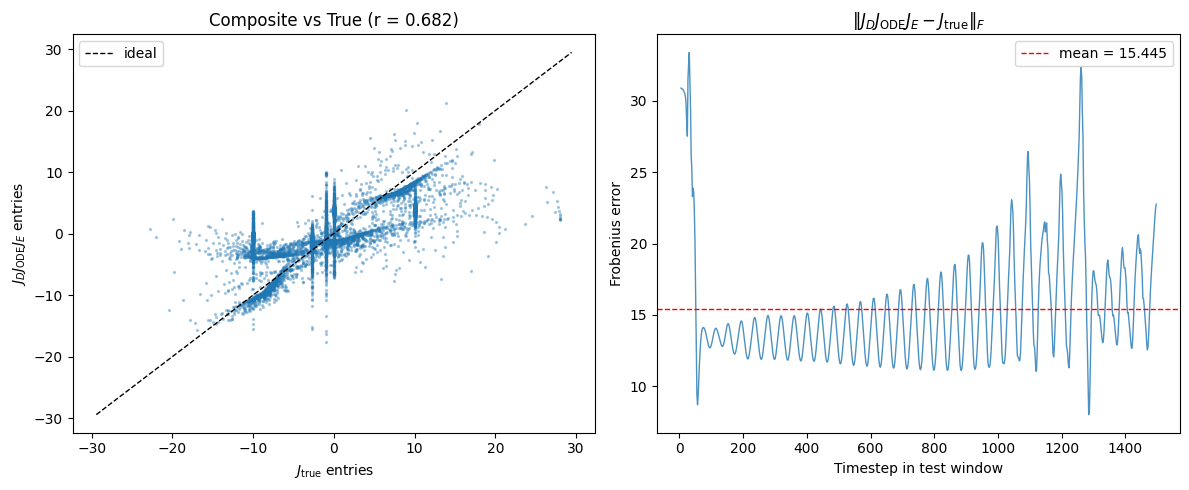

In [33]:
# ---------------------------------------------------------------
# Scatter plot: composite vs true entries  (all timesteps, all 9 entries)
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Scatter plot ---
ax = axes[0]
ax.scatter(true_flat, comp_flat, s=2, alpha=0.3, color='C0', rasterized=True)
lim = max(abs(true_flat).max(), abs(comp_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.0, label='ideal')
ax.set_xlabel("$J_{\\mathrm{true}}$ entries")
ax.set_ylabel("$J_D J_{\\mathrm{ODE}} J_E$ entries")
ax.set_title(f"Composite vs True (r = {corr:.3f})")
ax.legend()

# --- Frobenius error over time ---
ax2 = axes[1]
ax2.plot(list(t_indices), frob_errors.numpy(), lw=1.0, alpha=0.8)
ax2.axhline(frob_errors.mean().item(), color='r', ls='--', lw=1.0,
            label=f'mean = {frob_errors.mean():.3f}')
ax2.set_xlabel("Timestep in test window")
ax2.set_ylabel("Frobenius error")
ax2.set_title("$\|J_D J_{\\mathrm{ODE}} J_E - J_{\\mathrm{true}}\|_F$")
ax2.legend()

plt.tight_layout()
plt.show()

/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


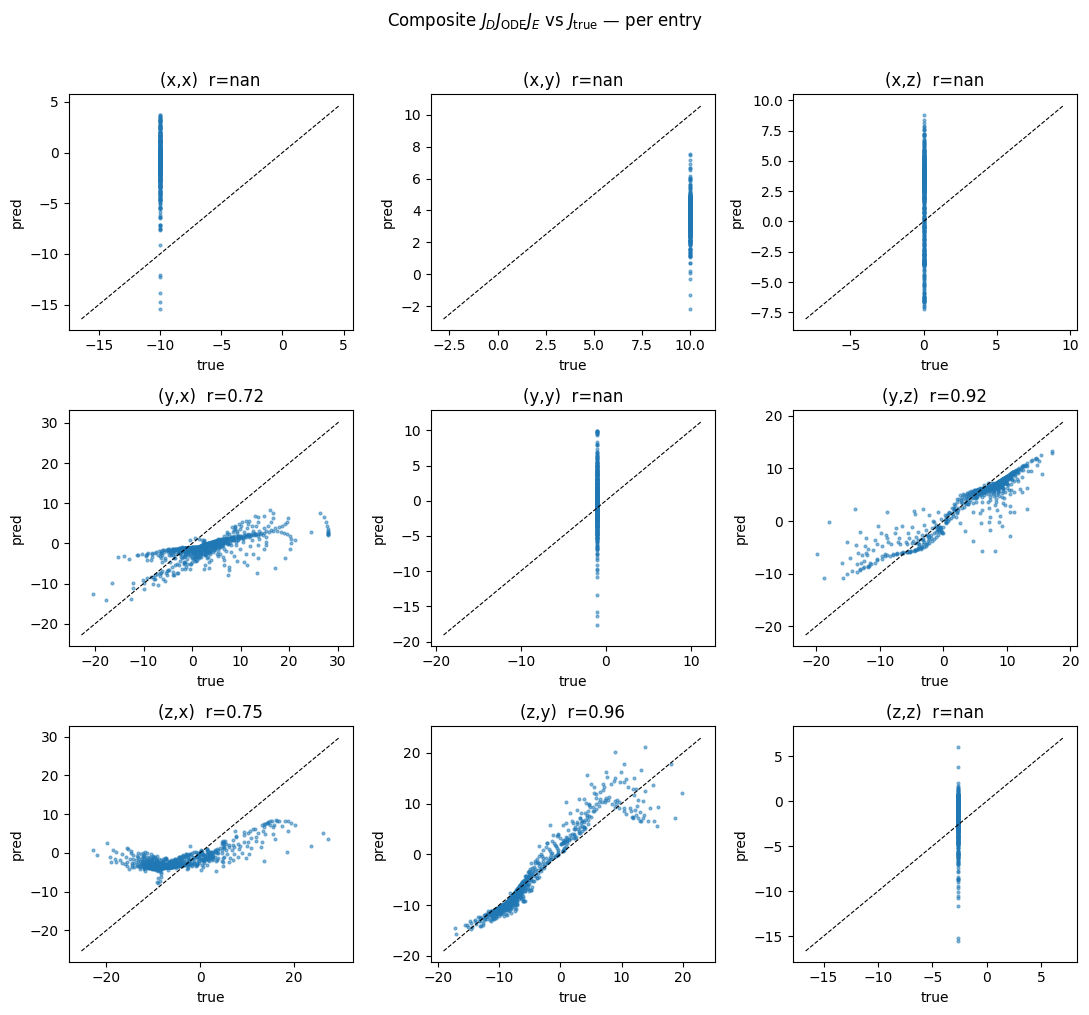

In [34]:
# ---------------------------------------------------------------
# Per-entry (i,j) scatter:  one subplot per Jacobian entry
# ---------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(11, 10))
row_labels = ['x', 'y', 'z']
col_labels = ['x', 'y', 'z']

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        c  = J_composites[:, i, j].numpy()
        t  = J_trues[:, i, j].numpy()
        r  = float(np.corrcoef(c, t)[0, 1]) if np.std(c) > 1e-8 and np.std(t) > 1e-8 else float('nan')

        ax.scatter(t, c, s=4, alpha=0.5, color='C0', rasterized=True)
        mn, mx = min(t.min(), c.min()), max(t.max(), c.max())
        pad = (mx - mn) * 0.05 if mx > mn else 0.1
        ax.plot([mn-pad, mx+pad], [mn-pad, mx+pad], 'k--', lw=0.8)
        ax.set_title(f"({row_labels[i]},{col_labels[j]})  r={r:.2f}")
        ax.set_xlabel("true")
        ax.set_ylabel("pred")

fig.suptitle("Composite $J_D J_{\\mathrm{ODE}} J_E$ vs $J_{\\mathrm{true}}$ — per entry", y=1.01)
plt.tight_layout()
plt.show()

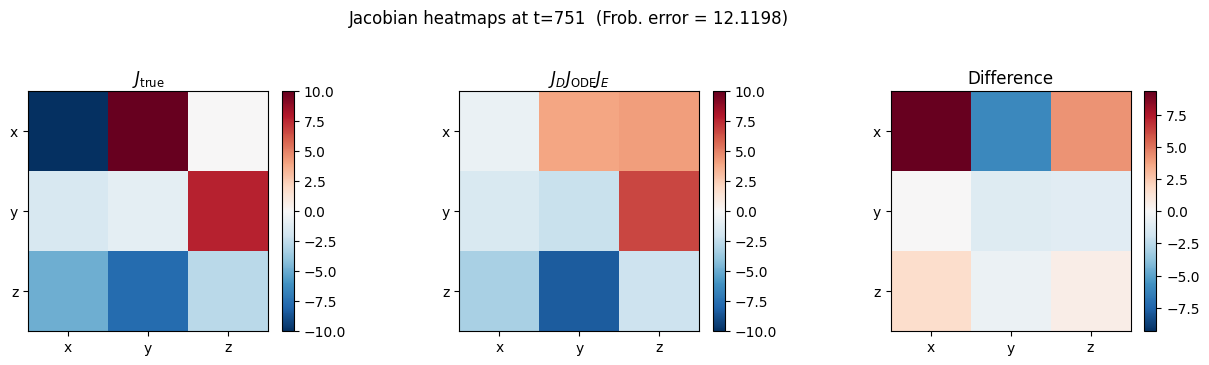

In [35]:
# ---------------------------------------------------------------
# Heatmap comparison at a single representative timestep
# ---------------------------------------------------------------
mid = len(t_indices) // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

vabs = max(J_trues[mid].abs().max().item(),
           J_composites[mid].abs().max().item())

im0 = axes[0].imshow(J_trues[mid].numpy(),      vmin=-vabs, vmax=vabs, cmap='RdBu_r')
im1 = axes[1].imshow(J_composites[mid].numpy(), vmin=-vabs, vmax=vabs, cmap='RdBu_r')
diff = (J_composites[mid] - J_trues[mid]).numpy()
im2 = axes[2].imshow(diff, cmap='RdBu_r',
                     vmin=-abs(diff).max(), vmax=abs(diff).max())

for ax, im, title in zip(axes, [im0, im1, im2],
                          ['$J_{\\mathrm{true}}$',
                           '$J_D J_{\\mathrm{ODE}} J_E$',
                           'Difference']):
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['x', 'y', 'z'])
    ax.set_yticklabels(['x', 'y', 'z'])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

t_shown = list(t_indices)[mid]
fig.suptitle(f"Jacobian heatmaps at t={t_shown}  "
             f"(Frob. error = {frob_errors[mid]:.4f})", y=1.03)
plt.tight_layout()
plt.show()

## 10. Summary

| Test | Metric | Target | Result |
|------|--------|--------|--------|
| **Lyapunov exponents** | MSE vs true | < 1.0 | `lyap_mse` above |
| **Composite Jacobian** | Entry correlation | > 0.9 | `corr` above |
| **Composite Jacobian** | Mean relative Frob. error | < 0.3 | `rel_errors.mean()` above |

If both tests pass, the Latent JacobianODE correctly encodes, predicts, and decodes
the dynamics of the fully-observed 3D system — validating the end-to-end pipeline
before moving to partial observation or higher-dimensional latent spaces.

### Hyperparameter Reference

| Category | Parameter | Value | Notes |
|----------|-----------|-------|-------|
| **System** | Observed dims | 3/3 | Fully observed |
| **Latent** | `N_LATENT` | 3 | Exact dimension match |
| **LRU** | `d_model` | 64 | Internal channel width |
| **LRU** | `d_state` | 32 | Complex state per channel |
| **LRU** | `n_layers` | 3 | Stacked LRU layers |
| **LRU** | `r_min` / `r_max` | 0.0 / 0.99 | Initial \|λ\| range; increase `r_min` for longer memory |
| **LRU** | `ffn_expand` | 2 | GEGLU FFN hidden dim = `d_model × ffn_expand` |
| **LRU** | `use_positional_encoding` | False | No PE — recurrent state encodes time order |
| **JacMLP** | `hidden_dim` | [512,512,512] | 3D system only needs small MLP |
| **JacODE** | `traj_init_steps` | 15 | Init steps |
| **JacODE** | `prediction_steps` | 10 | Pred steps |
| **Batch** | `SEQ_LENGTH` | 50 | Window length |
| **Batch** | `JAC_WINDOW_STRIDE` | 5 | Sub-window stride → 6 windows/batch |
| **Batch** | `BATCH_SIZE` | 32 | Batch size |